In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from mpl_toolkits.mplot3d import Axes3D
from WelfareMeasures import *
from functions_njit import tax_rate_fct
from bernoulli_distribution import Bernoulli
from help_functions_non_njit import *
from graph_format import *
# load local model file and initialize model class
from model import ModelClass
from scipy.optimize import minimize

# Load original model

In [2]:
model = ModelClass() # set a few number of periods.

par = model.par
sol = model.sol
sim = model.sim
par.opt_tol = 1e-6
par.opt_maxiter = 1000

%time model.solve(do_print=False)
%time model.simulate()

CPU times: total: 12min 46s
Wall time: 3min 15s
CPU times: total: 42.7 s
Wall time: 27 s


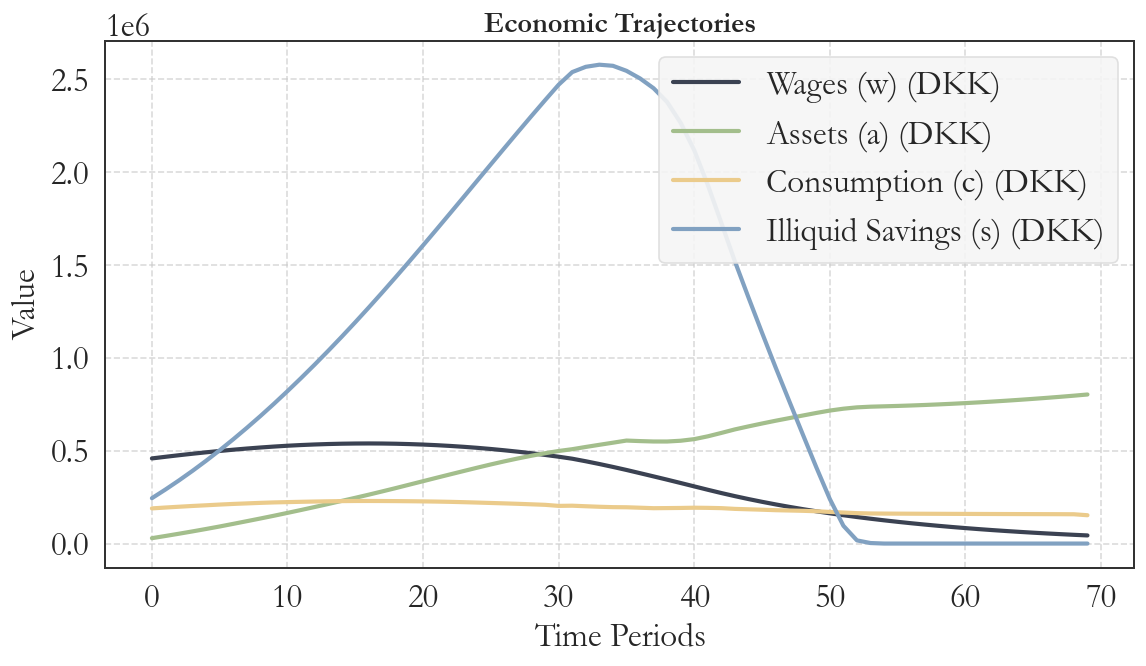

In [3]:
time = np.arange(par.T)
data_dict_basic = {
    "Wages (w)": {"data": np.mean(model.sim.w[:], axis=0), "unit": "DKK"},
    "Assets (a)": {"data": np.mean(model.sim.a[:], axis=0), "unit": "DKK"},
    "Consumption (c)": {"data": np.mean(model.sim.c[:], axis=0), "unit": "DKK"},
    "Illiquid Savings (s)": {"data": np.mean(model.sim.s[:], axis=0), "unit": "DKK"},
}

plot_simulation_one_graph(data_dict_basic, time, title="Economic Trajectories")

# Counter factual

In [4]:
# Change parameters and re-solve
theta = [31, 36] # Jeg har slukket for opdatering af first_retirement, hvor den opdateres herinde. Early forskydes, hvis first forskydes
theta_names = ['first_retirement','retirement_age']

og_model, new_model =  make_new_model(model, theta, theta_names, do_print = False)


# Labor supply

c:\Users\Peter\Desktop\Speciale\Design_retirement - Copy\WelfareMeasures.py:83: RuntimeWarning: Mean of empty slice
  sim_og_h = np.nanmean(sim_og_h_ex_1, axis=0)# age specific average
c:\Users\Peter\Desktop\Speciale\Design_retirement - Copy\WelfareMeasures.py:84: RuntimeWarning: Mean of empty slice
  sim_new_h = np.nanmean(sim_new_h_ex_1, axis=0) # age specific average


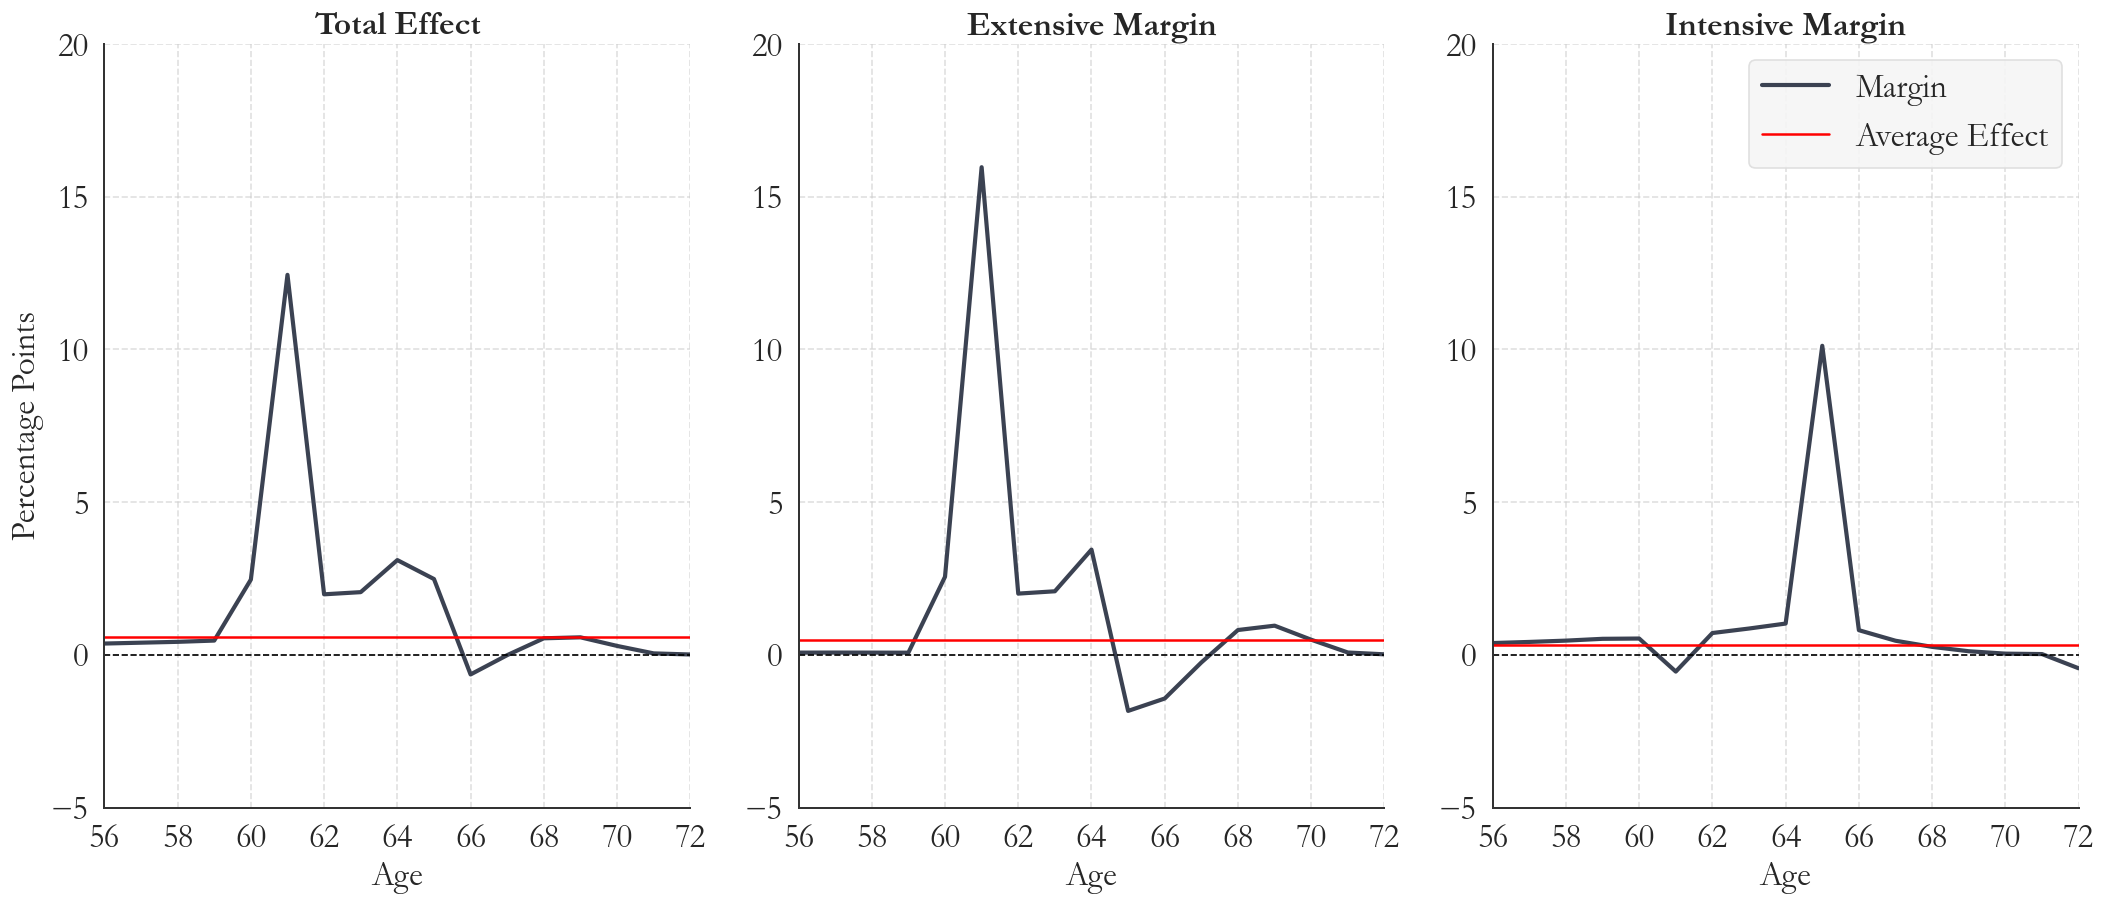

In [5]:
# Compare models 
# consumption_eq = find_consumption_equivalence(og_model, new_model, do_print= True, the_method = 'brentq')
intensive_margin, extensive_margin, total_margin, total_per_person, intensive_margin_age, extensive_margin_age, total_margin_age  = labor_elasticity(og_model, new_model)


plot_labor_margins_by_age(
    intensive_age=intensive_margin_age,
    extensive_age=extensive_margin_age,
    total_age=total_margin_age,
    avg_intensive=intensive_margin,
    avg_extensive=extensive_margin,
    avg_total=total_margin,
    age_start=par.start_age,
    # title_prefix="Labor Supply — ",
    save_title="CF_r_age_66_everything_labor.png",
    ylim_total=(-5, 20),
    ylim_extensive=(-5, 20),
    ylim_intensive=(-5, 20)
)

In [6]:
total_margin

0.0056728271809532915

In [7]:
pi_cum = np.cumprod(par.pi)

total_margin_og = np.mean(pi_cum[:og_model.par.last_retirement] * og_model.sim.h[:, :og_model.par.last_retirement])
total_margin_new = np.mean(pi_cum[:og_model.par.last_retirement] * new_model.sim.h[:, :og_model.par.last_retirement])
test = (total_margin_new-total_margin_og)/total_margin_og

test

0.012297480776293435

Retirement age only

In [19]:
# Change parameters and re-solve
theta = [36]
theta_names = ['retirement_age'] #jeg har slukket for at first også bliver forskudt, som forhindrer at early forskydes

og_model, new_model =  make_new_model(model, theta, theta_names, do_print = False)


Expected welfare  before parameter changes: -22.12986137403131
Expected welfare after parameter changes: -22.128576610526707
Consumption at every age before the policy change must change with 0.0 pct. to keep the same utility, and analytically: 0.0 pct.


c:\Users\Peter\Desktop\Speciale\Design_retirement - Copy\WelfareMeasures.py:83: RuntimeWarning: Mean of empty slice
  sim_og_h = np.nanmean(sim_og_h_ex_1, axis=0)# age specific average
c:\Users\Peter\Desktop\Speciale\Design_retirement - Copy\WelfareMeasures.py:84: RuntimeWarning: Mean of empty slice
  sim_new_h = np.nanmean(sim_new_h_ex_1, axis=0) # age specific average


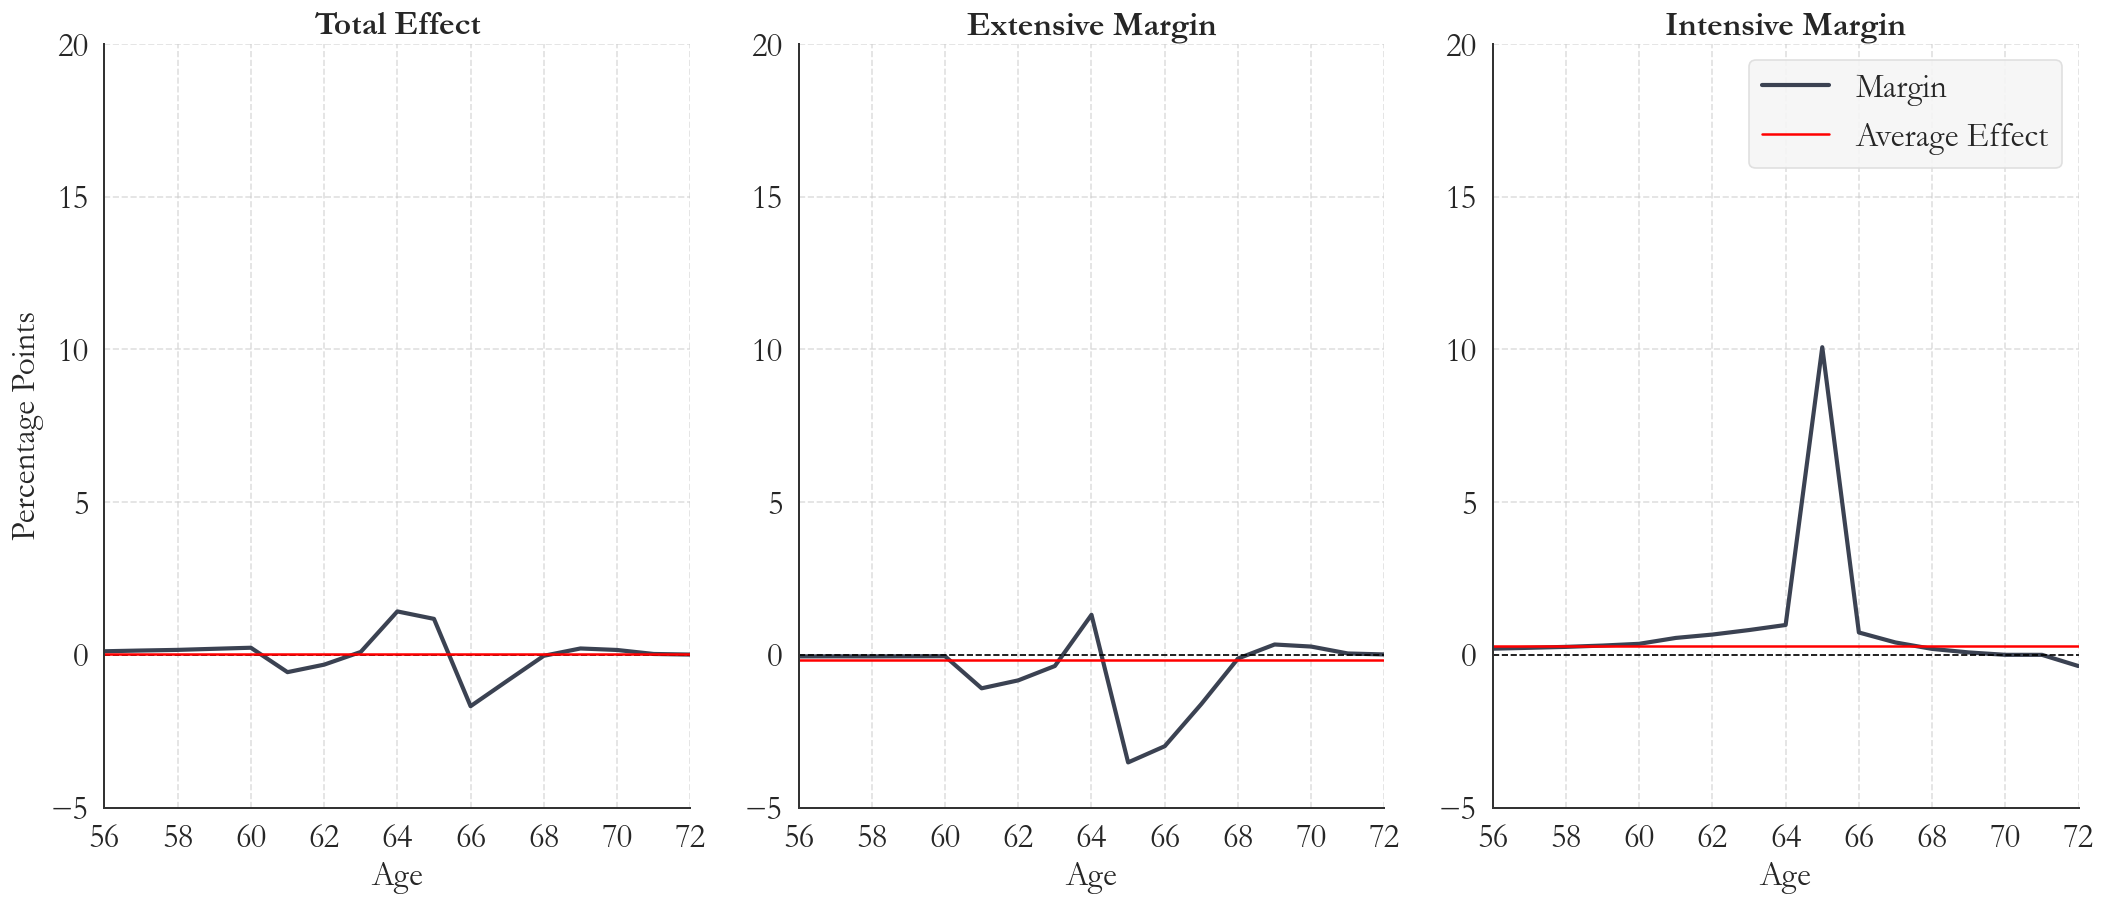

0.00011732254964673058

In [20]:
# Compare models 
consumption_eq = find_consumption_equivalence(og_model, new_model, do_print= True, the_method = 'brentq')
intensive_margin, extensive_margin, total_margin, total_per_person, intensive_margin_age, extensive_margin_age, total_margin_age  = labor_elasticity(og_model, new_model)


plot_labor_margins_by_age(
    intensive_age=intensive_margin_age,
    extensive_age=extensive_margin_age,
    total_age=total_margin_age,
    avg_intensive=intensive_margin,
    avg_extensive=extensive_margin,
    avg_total=total_margin,
    age_start=par.start_age,
    # title_prefix="Labor Supply — ",
    save_title="CF_r_age_66_labor.png",
    ylim_total=(-5, 20),
    ylim_extensive=(-5, 20),
    ylim_intensive=(-5, 20)
)

total_margin

Only retirement age

In [21]:
# Change parameters and re-solve
theta = [2]
theta_names = ['early_benefits_lag']

og_model, new_model =  make_new_model(model, theta, theta_names, do_print = False)


Expected welfare  before parameter changes: -22.12986137403131
Expected welfare after parameter changes: -22.132915098039284
Consumption at every age before the policy change must change with -0.1 pct. to keep the same utility, and analytically: -0.1 pct.


c:\Users\Peter\Desktop\Speciale\Design_retirement - Copy\WelfareMeasures.py:83: RuntimeWarning: Mean of empty slice
  sim_og_h = np.nanmean(sim_og_h_ex_1, axis=0)# age specific average
c:\Users\Peter\Desktop\Speciale\Design_retirement - Copy\WelfareMeasures.py:84: RuntimeWarning: Mean of empty slice
  sim_new_h = np.nanmean(sim_new_h_ex_1, axis=0) # age specific average


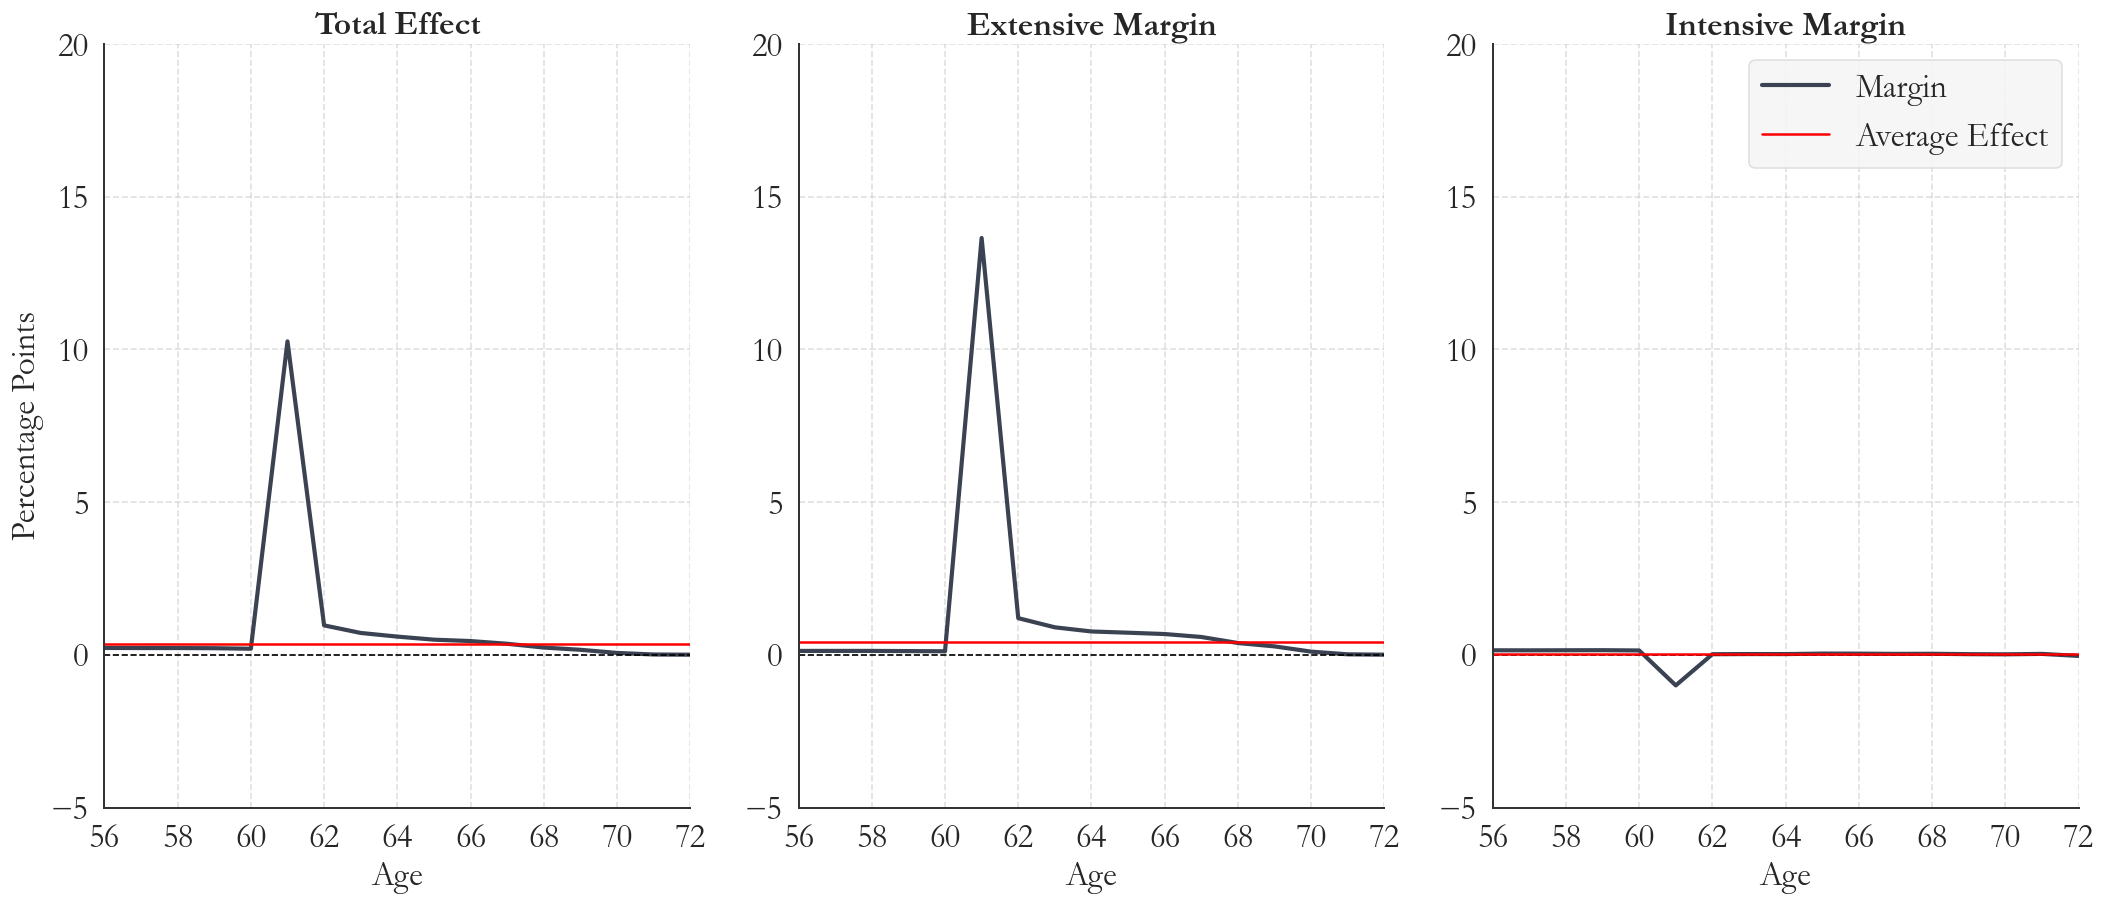

0.0036132420696988587

In [22]:
# Compare models 
consumption_eq = find_consumption_equivalence(og_model, new_model, do_print= True, the_method = 'brentq')
intensive_margin, extensive_margin, total_margin, total_per_person, intensive_margin_age, extensive_margin_age, total_margin_age  = labor_elasticity(og_model, new_model)


plot_labor_margins_by_age(
    intensive_age=intensive_margin_age,
    extensive_age=extensive_margin_age,
    total_age=total_margin_age,
    avg_intensive=intensive_margin,
    avg_extensive=extensive_margin,
    avg_total=total_margin,
    age_start=par.start_age,
    # title_prefix="Labor Supply — ",
    save_title="CF_ef_age_2_labor.png",
    ylim_total=(-5, 20),
    ylim_extensive=(-5, 20),
    ylim_intensive=(-5, 20)
)

total_margin

c:\Users\Peter\Desktop\Speciale\Design_retirement - Copy\WelfareMeasures.py:83: RuntimeWarning: Mean of empty slice
  sim_og_h = np.nanmean(sim_og_h_ex_1, axis=0)# age specific average
c:\Users\Peter\Desktop\Speciale\Design_retirement - Copy\WelfareMeasures.py:84: RuntimeWarning: Mean of empty slice
  sim_new_h = np.nanmean(sim_new_h_ex_1, axis=0) # age specific average
c:\Users\Peter\Desktop\Speciale\Design_retirement - Copy\WelfareMeasures.py:83: RuntimeWarning: Mean of empty slice
  sim_og_h = np.nanmean(sim_og_h_ex_1, axis=0)# age specific average
c:\Users\Peter\Desktop\Speciale\Design_retirement - Copy\WelfareMeasures.py:84: RuntimeWarning: Mean of empty slice
  sim_new_h = np.nanmean(sim_new_h_ex_1, axis=0) # age specific average
c:\Users\Peter\Desktop\Speciale\Design_retirement - Copy\WelfareMeasures.py:83: RuntimeWarning: Mean of empty slice
  sim_og_h = np.nanmean(sim_og_h_ex_1, axis=0)# age specific average
c:\Users\Peter\Desktop\Speciale\Design_retirement - Copy\WelfareMeasu

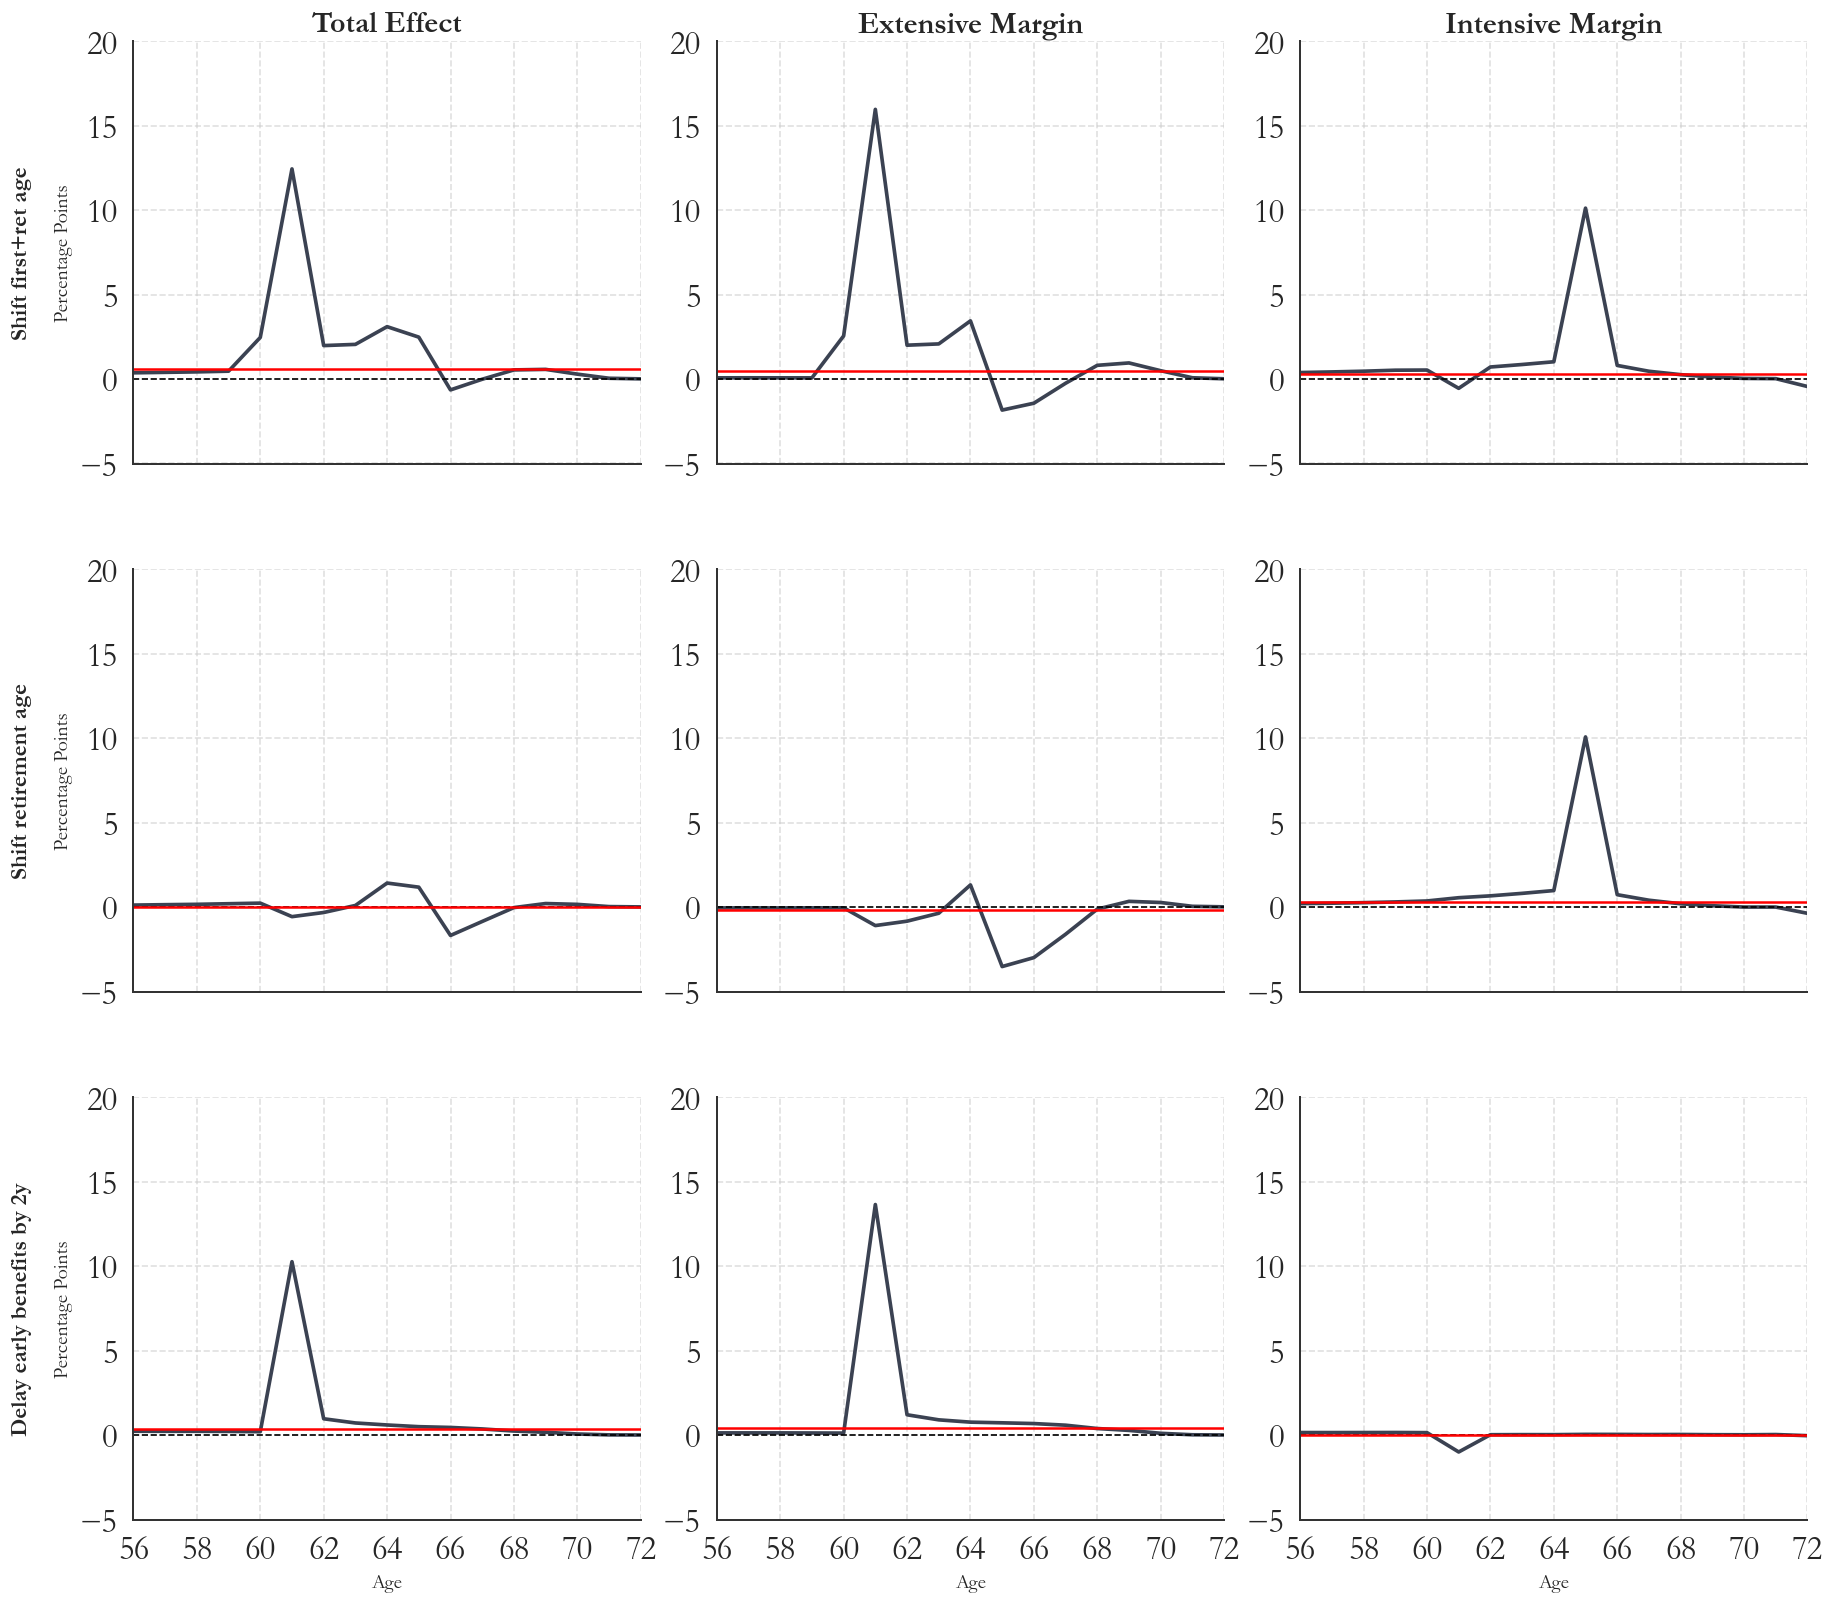

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd  # only if you want to log results; otherwise not needed

# --- helper: run one scenario and return age series + averages ---
def _run_scenario(model, theta, theta_names, label):
    og_model, new_model = make_new_model(model, theta, theta_names, do_print=False)
    intens, extens, total, _, intens_age, extens_age, total_age = labor_elasticity(og_model, new_model)
    return {
        "label": label,
        "intensive_age": intens_age,
        "extensive_age": extens_age,
        "total_age": total_age,
        "avg_intensive": intens,
        "avg_extensive": extens,
        "avg_total": total,
        "age_start": og_model.par.start_age,
    }

# --- main: plot 3x3 grid (rows=scenarios, cols=metrics) ---
def plot_labor_margins_3x3(
    model,
    scenarios,
    first_age=56,
    last_age=72,
    col_titles=("Total Effect", "Extensive Margin", "Intensive Margin"),
    ylim_total=(-5, 25),
    ylim_extensive=(-5, 25),
    ylim_intensive=(-5, 25),
    save_title=None
):
    """
    scenarios: list of tuples (theta, theta_names, label)
    """
    # 1) compute results for each scenario
    results = [_run_scenario(model, th, names, label) for th, names, label in scenarios]

    # 2) build grid
    fig, axes = plt.subplots(3, 3, figsize=(18, 16), sharex="col")
    fig.subplots_adjust(hspace=0.25, wspace=0.15)

    # 3) column titles (top row)
    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title, fontsize=18, fontweight="bold")

    # 4) per-column settings
    col_specs = [
        ("total_age",     "avg_total",     ylim_total),
        ("extensive_age", "avg_extensive", ylim_extensive),
        ("intensive_age", "avg_intensive", ylim_intensive),
    ]

    for i, res in enumerate(results):
        # age mask
        ages_full = np.arange(res["age_start"], res["age_start"] + len(res["intensive_age"]))
        mask = (ages_full >= first_age) & (ages_full <= last_age)
        ages = ages_full[mask]

        # left-side row labels: scenario names
        axes[i, 0].annotate(
            res["label"],
            xy=(0, 0.5),
            xycoords=("axes fraction", "axes fraction"),
            xytext=(-0.20, 0.5),
            textcoords=("axes fraction", "axes fraction"),
            ha="right", va="center",
            fontsize=14, fontweight="bold",
            rotation=90
        )

        for j, (series_key, avg_key, ylim_) in enumerate(col_specs):
            ax = axes[i, j]
            series = res[series_key][mask] * 100.0
            avg = res[avg_key] * 100.0

            ax.plot(ages, series, color=custom_palette[0], linewidth=2.2)
            ax.axhline(0, color="black", linestyle="--", linewidth=1)
            ax.axhline(avg, color="red", linestyle="-", linewidth=1.5)

            ax.set_xlim(first_age, last_age)
            ax.set_ylim(*ylim_)
            ax.set_xticks(np.arange(first_age, last_age + 1, 2))
            ax.grid(True, linestyle="--", alpha=0.6)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            # y-label only on first column
            if j == 0:
                ax.set_ylabel("Percentage Points", fontsize=12)

            # x-label only on bottom row
            if i == len(results) - 1:
                ax.set_xlabel("Age", fontsize=12)

    if save_title:
        save_figure(fig, save_title)

    plt.show()


# -------------------------
# Example usage (mirrors your three policy runs)
# -------------------------
scenarios = [
    ([31, 36], ['first_retirement', 'retirement_age'], "Shift first+ret age"),
    ([36],      ['retirement_age'],                     "Shift retirement age"),
    ([2],       ['early_benefits_lag'],                 "Delay early benefits by 2y"),
]

plot_labor_margins_3x3(
    model,
    scenarios,
    first_age=56,
    last_age=72,
    col_titles=("Total Effect", "Extensive Margin", "Intensive Margin"),
    ylim_total=(-5, 20),
    ylim_extensive=(-5, 20),
    ylim_intensive=(-5, 20),
    save_title="labor_margins_3x3.png"
)


c:\Users\Peter\Desktop\Speciale\Design_retirement - Copy\WelfareMeasures.py:83: RuntimeWarning: Mean of empty slice
  sim_og_h = np.nanmean(sim_og_h_ex_1, axis=0)# age specific average
c:\Users\Peter\Desktop\Speciale\Design_retirement - Copy\WelfareMeasures.py:84: RuntimeWarning: Mean of empty slice
  sim_new_h = np.nanmean(sim_new_h_ex_1, axis=0) # age specific average
c:\Users\Peter\Desktop\Speciale\Design_retirement - Copy\WelfareMeasures.py:83: RuntimeWarning: Mean of empty slice
  sim_og_h = np.nanmean(sim_og_h_ex_1, axis=0)# age specific average
c:\Users\Peter\Desktop\Speciale\Design_retirement - Copy\WelfareMeasures.py:84: RuntimeWarning: Mean of empty slice
  sim_new_h = np.nanmean(sim_new_h_ex_1, axis=0) # age specific average
c:\Users\Peter\Desktop\Speciale\Design_retirement - Copy\WelfareMeasures.py:83: RuntimeWarning: Mean of empty slice
  sim_og_h = np.nanmean(sim_og_h_ex_1, axis=0)# age specific average
c:\Users\Peter\Desktop\Speciale\Design_retirement - Copy\WelfareMeasu

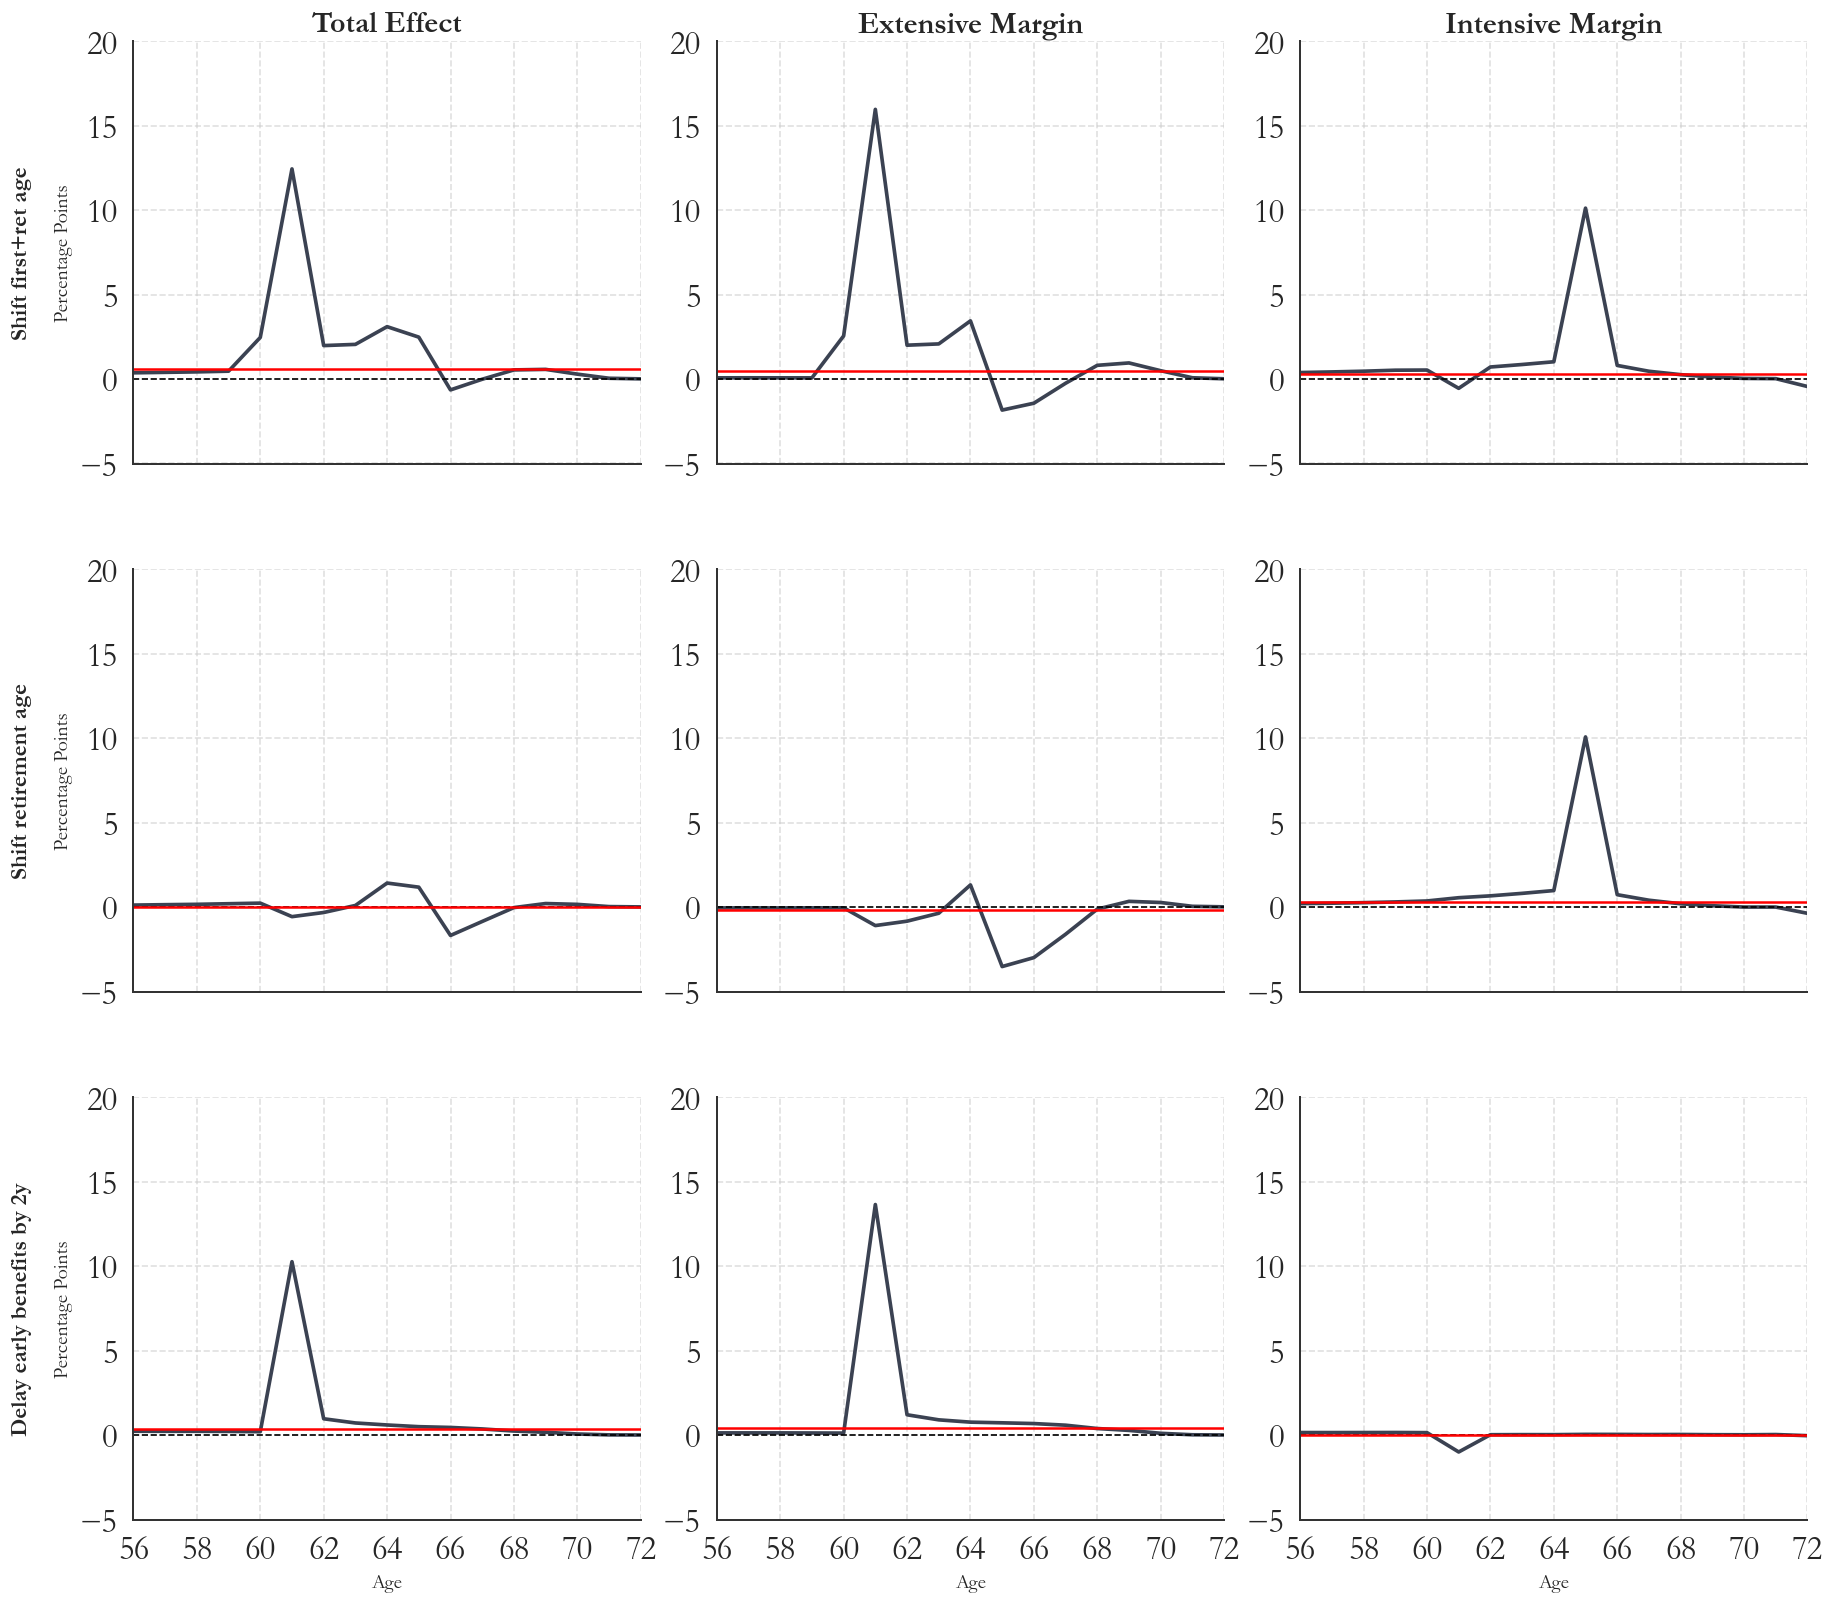

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

# ---------- 1) COMPUTE & STORE (run once) ----------
def compute_labor_margins_scenarios(model, scenarios):
    """
    Run all policy scenarios and return a dict keyed by scenario label.
    scenarios: list of tuples (theta, theta_names, label)
    """
    store = OrderedDict()
    for theta, theta_names, label in scenarios:
        og_model, new_model = make_new_model(model, theta, theta_names, do_print=False)
        intens, extens, total, _, intens_age, extens_age, total_age = labor_elasticity(og_model, new_model)

        store[label] = {
            "age_start": og_model.par.start_age,
            "intensive_age": intens_age,      # arrays at age-level
            "extensive_age": extens_age,
            "total_age": total_age,
            "avg_intensive": intens,          # scalars (averages)
            "avg_extensive": extens,
            "avg_total": total,
        }
    return store



# ---------- Example usage ----------
scenarios = [
    ([31, 36], ['first_retirement', 'retirement_age'], "Shift first+ret age"),
    ([36],      ['retirement_age'],                     "Shift retirement age"),
    ([2],       ['early_benefits_lag'],                 "Delay early benefits by 2y"),
]

# 1) Run once (slow) and store
store = compute_labor_margins_scenarios(model, scenarios)

# (Optional) persist for later sessions:
# import pickle
# with open("labor_margins_store.pkl", "wb") as f:
#     pickle.dump(store, f)




In [31]:
store

OrderedDict([('Shift first+ret age',
              {'age_start': 30,
               'intensive_age': array([-1.60570511e-05,  1.70723786e-05,  6.17134160e-05,  1.21986719e-04,
                       1.65004126e-04,  2.13189380e-04,  2.74344903e-04,  3.01446178e-04,
                       3.91037810e-04,  4.53190268e-04,  5.34818161e-04,  6.20009691e-04,
                       7.02981871e-04,  7.81852542e-04,  9.47045091e-04,  1.05829342e-03,
                       1.20456399e-03,  1.37285131e-03,  1.52855297e-03,  1.63396838e-03,
                       1.64438377e-03,  1.87897287e-03,  2.18491327e-03,  2.62971630e-03,
                       2.97871537e-03,  3.37897331e-03,  3.83371951e-03,  4.20000655e-03,
                       4.62516472e-03,  5.21884643e-03,  5.31097314e-03, -5.50633890e-03,
                       7.11449192e-03,  8.58685546e-03,  1.02127435e-02,  1.01137046e-01,
                       8.04075858e-03,  4.59199231e-03,  2.58285757e-03,  1.15201498e-03,
              

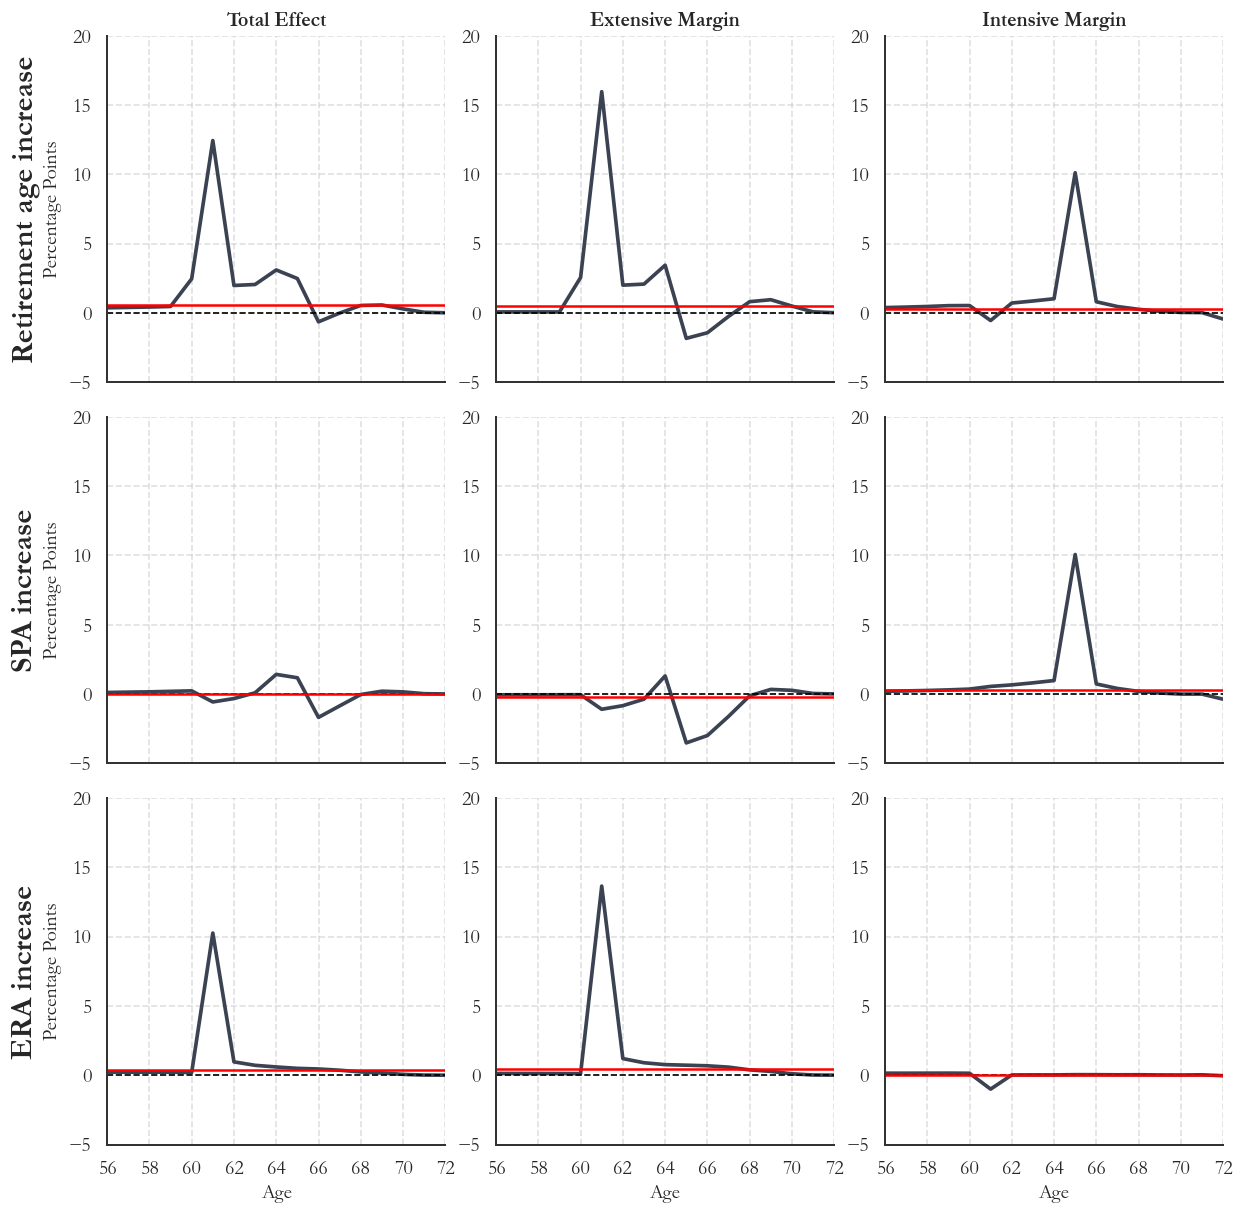

In [45]:
# ---------- 2) PLOT FROM STORED RESULTS (can tweak freely) ----------
def plot_labor_margins_3x3_from_store(
    store,
    first_age=56,
    last_age=72,
    col_titles=("Total Effect", "Extensive Margin", "Intensive Margin"),
    ylim_total=(-5, 20),
    ylim_extensive=(-5, 20),
    ylim_intensive=(-5, 20),
    save_title=None
):
    """
    store: dict[label] -> dict with keys:
        age_start, intensive_age, extensive_age, total_age, avg_intensive, avg_extensive, avg_total
    """
    labels = list(store.keys())
    if len(labels) != 3:
        # Keep strict 3x3 layout; extend as needed if you add more scenarios.
        labels = labels[:3]

    fig, axes = plt.subplots(3, 3, figsize=(12, 12), sharex="col")
    fig.subplots_adjust(hspace=0.1, wspace=0.15)

    # Column headers
    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title, fontsize=12, fontweight="bold")

    # Column specs: (series_key, avg_key, y-limits)
    col_specs = [
        ("total_age",     "avg_total",     ylim_total),
        ("extensive_age", "avg_extensive", ylim_extensive),
        ("intensive_age", "avg_intensive", ylim_intensive),
    ]

    for i, label in enumerate(labels):
        res = store[label]

        # Age mask
        ages_full = np.arange(res["age_start"], res["age_start"] + len(res["intensive_age"]))
        mask = (ages_full >= first_age) & (ages_full <= last_age)
        ages = ages_full[mask]

        # Row label on the left (rotated)
        axes[i, 0].annotate(
            label,
            xy=(0, 0.5),
            xycoords=("axes fraction", "axes fraction"),
            xytext=(-0.20, 0.5),
            textcoords=("axes fraction", "axes fraction"),
            ha="right", va="center",
            fontsize=18, fontweight="bold",
            rotation=90
        )

        for j, (series_key, avg_key, ylim_) in enumerate(col_specs):
            ax = axes[i, j]
            series = store[label][series_key][mask] * 100.0
            avg = store[label][avg_key] * 100.0

            ax.plot(ages, series, color=custom_palette[0], linewidth=2.2)
            ax.axhline(0, color="black", linestyle="--", linewidth=1)
            ax.axhline(avg, color="red", linestyle="-", linewidth=1.5)

            ax.set_xlim(first_age, last_age)
            ax.set_ylim(*ylim_)
            ax.set_xticks(np.arange(first_age, last_age + 1, 2))
            ax.grid(True, linestyle="--", alpha=0.6)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            if j == 0:
                ax.set_ylabel("Percentage Points", fontsize=12)
            if i == len(labels) - 1:
                ax.set_xlabel("Age", fontsize=12)

            ax.tick_params(labelsize=12)

    if save_title:
        save_figure(fig, save_title)

    plt.show()

# rename_map = {
#     "Shift first+ret age": "Retirement age increase",
#     "Shift retirement age": "SPA increase",
#     "Delay early benefits by 2y": "ERA increase",
# }

# for old_name, new_name in rename_map.items():
#     if old_name in store:
#         store[new_name] = store.pop(old_name)

# 2) Plot many times (fast) from 'store'
plot_labor_margins_3x3_from_store(
    store,
    first_age=56,
    last_age=72,
    ylim_total=(-5, 20),
    ylim_extensive=(-5, 20),
    ylim_intensive=(-5, 20),
    save_title="labor_margins_3x3.png"
)

# Consumption Equivalence - distribution

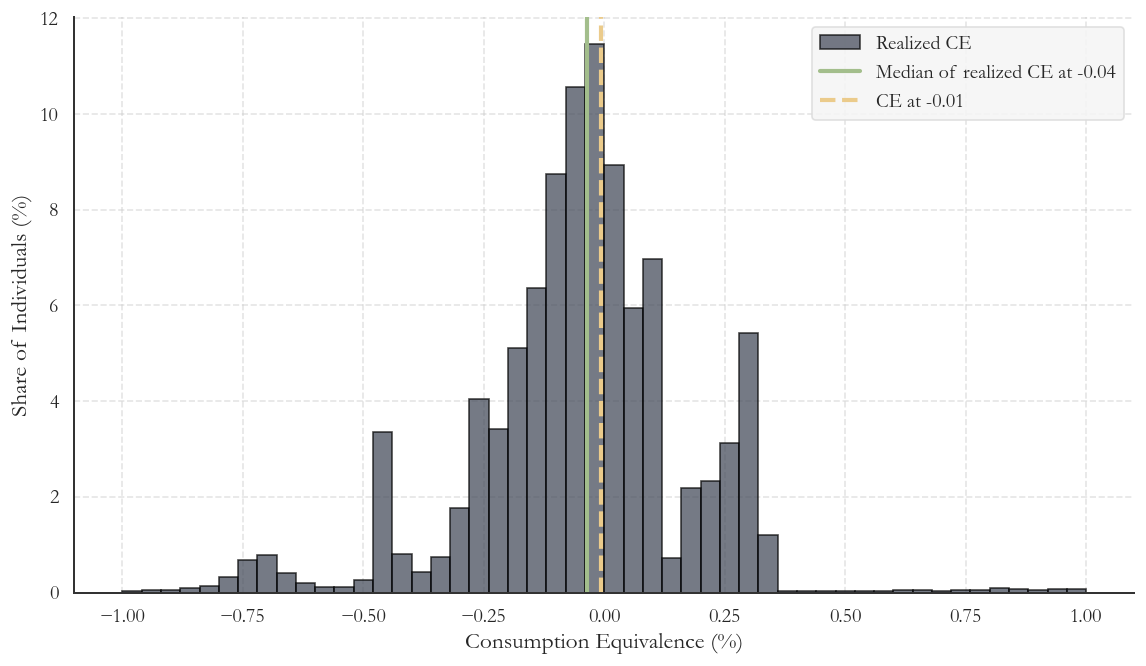

In [8]:
con_eq = analytical_consumption_equivalence_indi(og_model, new_model)
plot_event_histogram(con_eq[:]*100, 'Consumption Equivalence (%)', 
                    #  'Consumption Equivalence Distribution for a 30-year-old',
                         label1="Realized CE",
                         figsize=(10, 6), bins=50, range=(-1,1), median_val=np.median(con_eq)*100, mean_val =np.mean(con_eq)*100, save_title='CF_r_age_66_everything_CE_dist')

In [9]:
np.mean(con_eq*100< -0.25)

0.13954

In [10]:
np.mean(con_eq*100>0.25)

0.11952

# Unofficial retirement age

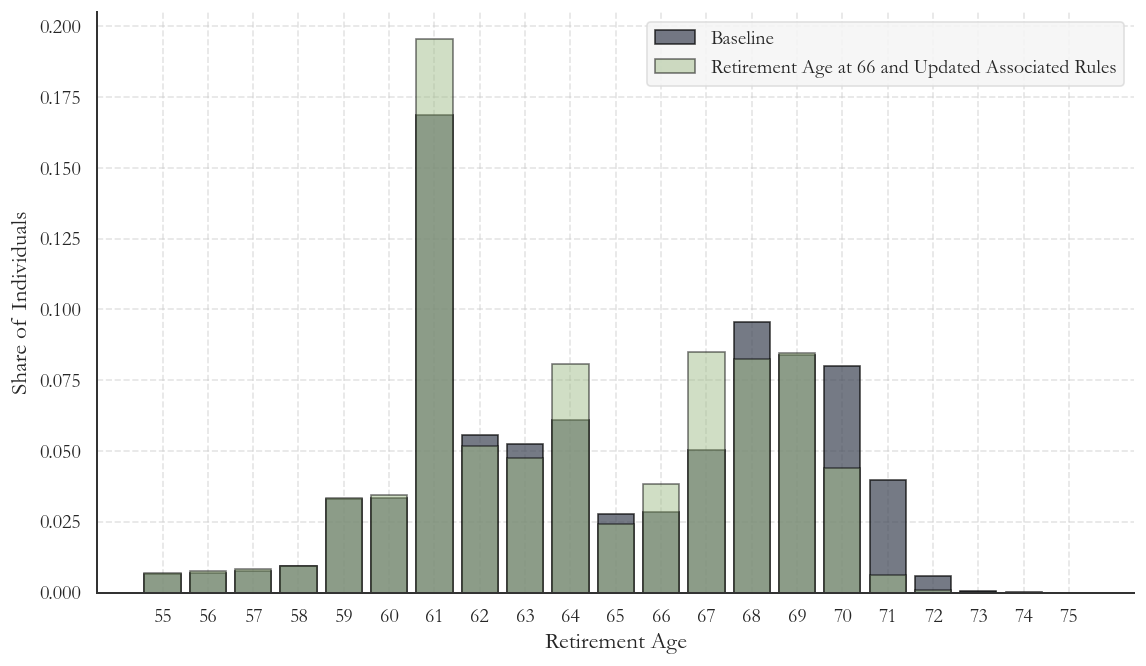

In [11]:
# 1. Find last time ex == 1 for each individual
last_working = np.full(og_model.sim.ex.shape[0], np.nan)  # initialize

for i in range(og_model.sim.ex.shape[0]):
    working = np.where(og_model.sim.ex[i, :] == 1)[0]  # find where ex=1
    if working.size > 0:
        last_working[i] = working[-1] +1  # last time they worked (take last index)

# 1. Find last time ex == 1 for each individual
last_working_new = np.full(new_model.sim.ex.shape[0], np.nan)  # initialize

for i in range(new_model.sim.ex.shape[0]):
    working_new = np.where(new_model.sim.ex[i, :] == 1)[0]  # find where ex=1
    if working_new.size > 0:
        last_working_new[i] = working_new[-1]  # last time they worked (take last index)

plot_event_bar_series(
    values1=last_working,
    values2=last_working_new,
    xlabel="Retirement Age",
    # title="Timing of Unofficial Retirement",
    label1="Baseline",
    label2="Retirement Age at 66 and Updated Associated Rules",
    bins=np.arange(25, 46),
    save_title="CF_r_age_66_everything_un_ret.png",
)


# Official retirement age

In [12]:
def official_retirement(model):
    first_retirement = np.full(model.sim.e.shape[0], np.nan)  # initialize

    for i in range(model.sim.e.shape[0]):
        retired = np.where(model.sim.e[i, :] == 2)[0]  # find where e=2
        if retired.size > 0:
            first_retirement[i] = retired[0]  # first time they retire
        if model.sim.efter_init[i]:
            if len(model.sim.ex[i,:]) - np.argmax(model.sim.ex[i,:][::-1] == 1)< first_retirement[i]:
                first_retirement[i] = len(model.sim.ex[i,:]) - np.argmax(model.sim.ex[i,:][::-1] == 1)

    return first_retirement

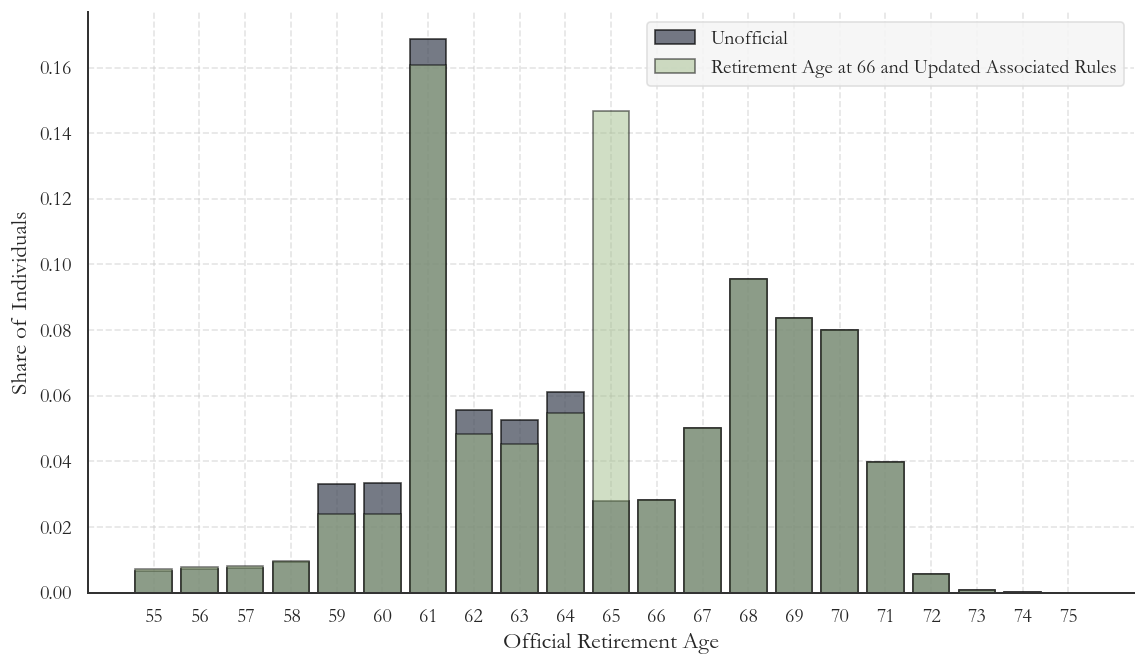

In [13]:
first_retirement_og = official_retirement(og_model)
first_retirement_new = official_retirement(new_model)

plot_event_bar_series(
    values1=last_working,
    values2=first_retirement_og,
    xlabel="Official Retirement Age",
    # title="Timing of Official Retirement",
    label1="Unofficial",
    label2="Retirement Age at 66 and Updated Associated Rules",
    bins=np.arange(25, 46),
    save_title="CF_r_age_66_everything_of_ret.png",
)


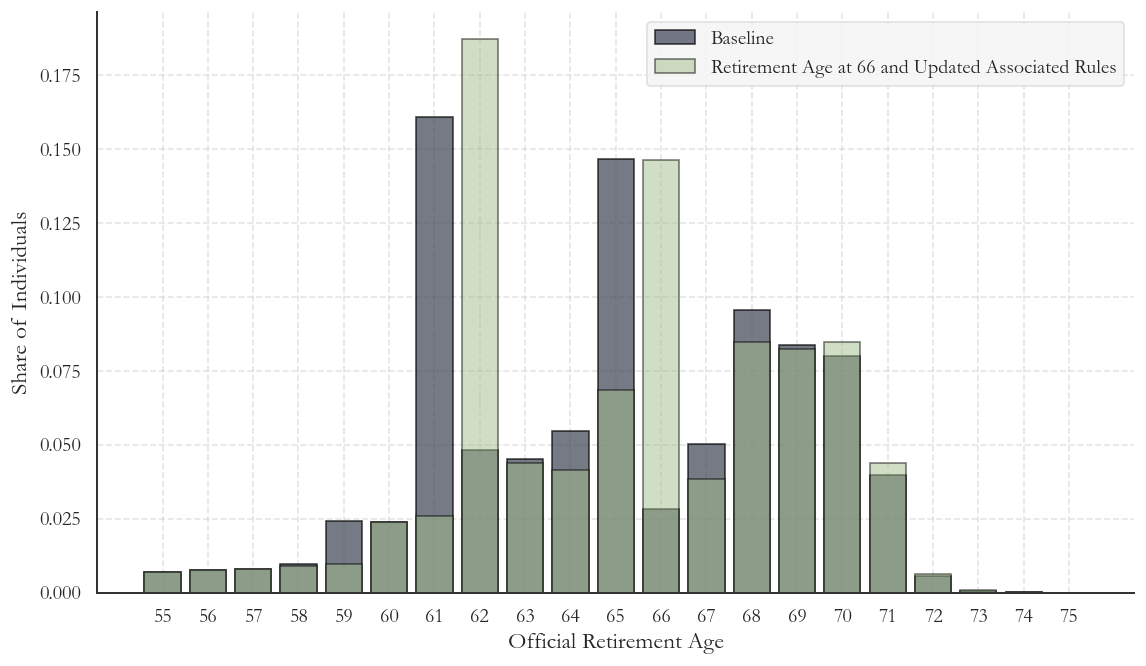

In [14]:
first_retirement_og = official_retirement(og_model)
first_retirement_new = official_retirement(new_model)

plot_event_bar_series(
    values1=first_retirement_og,
    values2=first_retirement_new,
    xlabel="Official Retirement Age",
    # title="Timing of Official Retirement",
    label1="Baseline",
    label2="Retirement Age at 66 and Updated Associated Rules",
    bins=np.arange(25, 46),
    save_title="CF_r_age_66_everything_of_ret.png",
)


# Voluntary retirement age

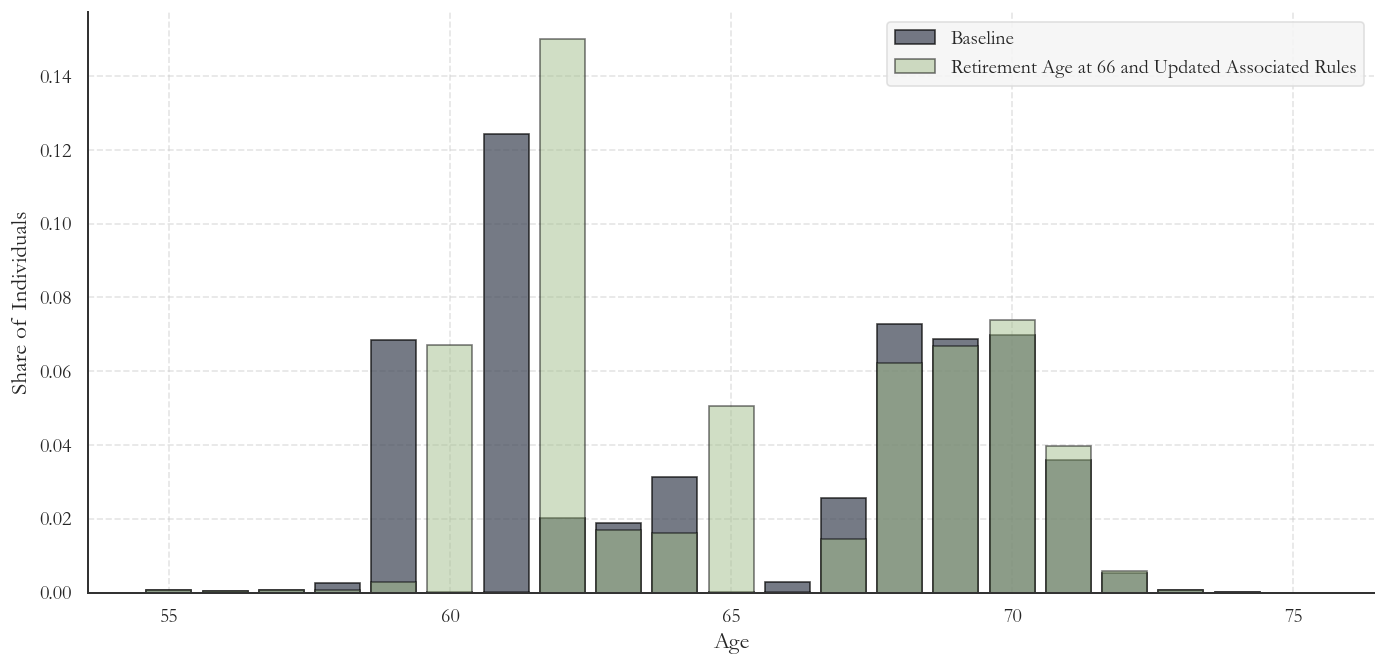

In [15]:
og_ret_counts = np.sum(og_model.sim.ret_flag[:, :], axis=0)
new_ret_counts = np.sum(new_model.sim.ret_flag[:, :], axis=0)
plot_bar_series_comparison(
    og_ret_counts,
    new_ret_counts,
    label1="Baseline",
    label2="Retirement Age at 66 and Updated Associated Rules",
    # title="Voluntary Retirements per Period",
    xlabel="Age",
    normalize=True,
    t_start=25, 
    t_end=46,
    save_title="CF_r_age_66_everything_vol_ret.png",
)


# Consumption Replacement Rate

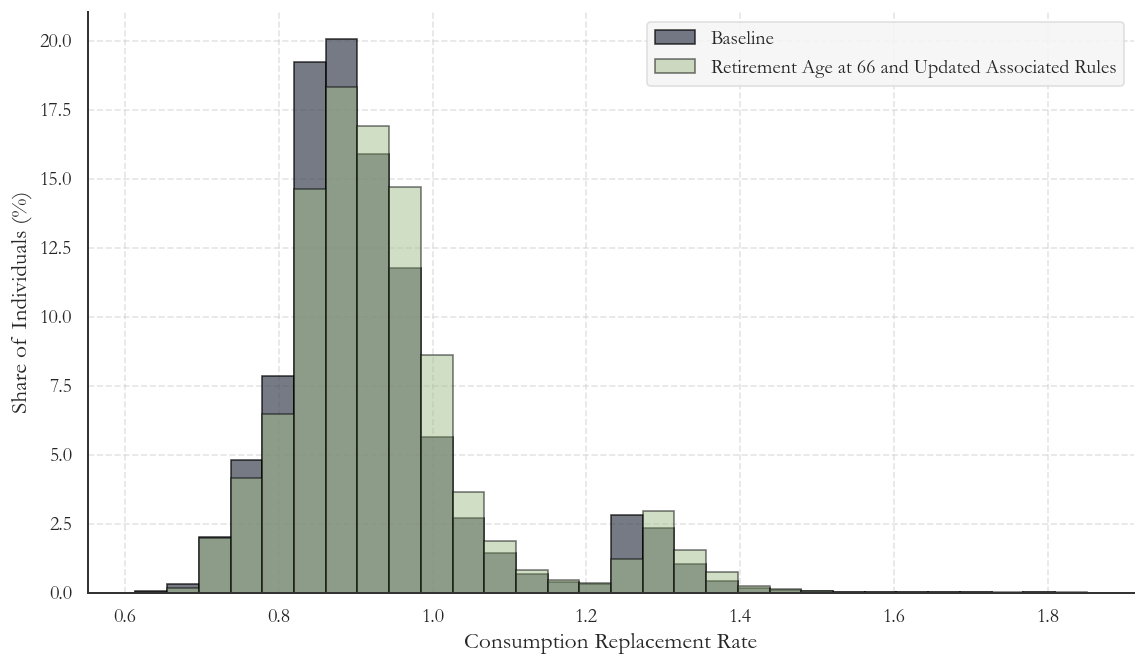

In [16]:
plot_event_histogram(
    values1=consumption_replacement_rate_fct(og_model),
    values2=consumption_replacement_rate_fct(new_model),
    xlabel="Consumption Replacement Rate",
    # title="Consumption Replacement Rate",
    label1="Baseline",
    label2="Retirement Age at 66 and Updated Associated Rules",
    bins=30,
    save_title="CF_r_age_66_everything_CR.png",
)

# Replacement Rate

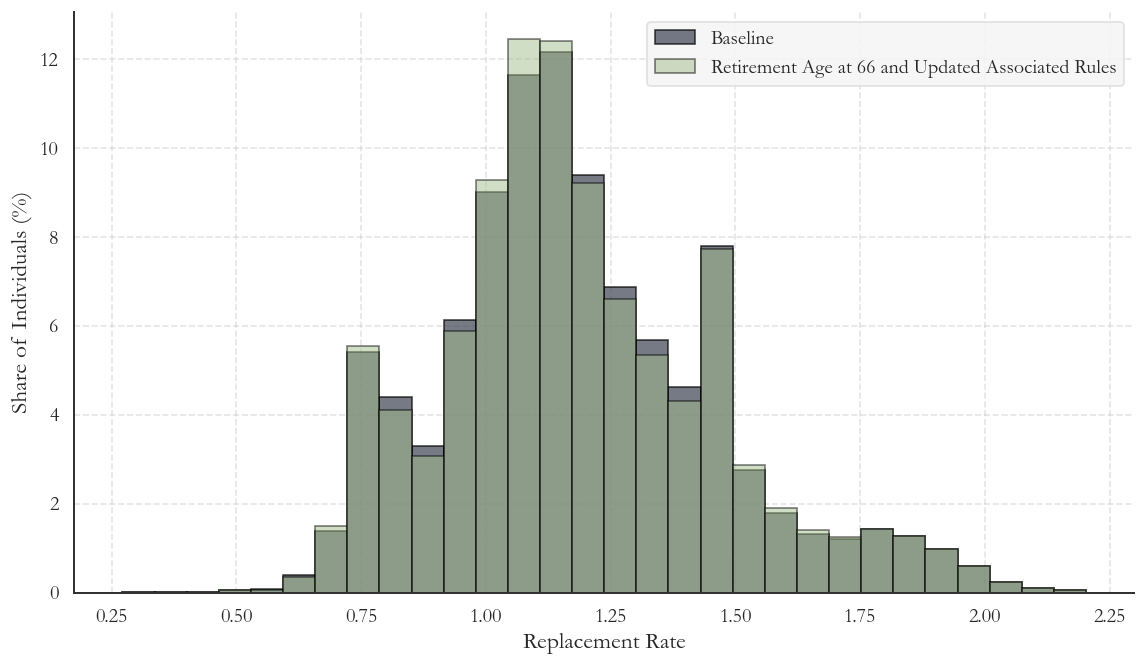

In [17]:
plot_event_histogram(
    values1=replacement_rate_fct(og_model),
    values2=replacement_rate_fct(new_model),
    xlabel="Replacement Rate",
    # title="Replacement Rate",
    label1="Baseline",
    label2="Retirement Age at 66 and Updated Associated Rules",
    bins=30,
    save_title="CF_r_age_66_everything_RR.png"
)


# Consumption equivalence over Age

In [18]:
EV_age_new

NameError: name 'EV_age_new' is not defined

In [ ]:
EV_age_og, EV_weight_og = ev_model(og_model)

In [ ]:
np.array(EV_age_new) - np.array(EV_age_og)

array([-3.77580331e-04, -2.94497085e-04, -2.13661410e-04, -1.33574902e-04,
       -5.79161109e-05,  1.94322525e-05,  9.97478252e-05,  1.78815837e-04,
        2.52997298e-04,  3.41527007e-04,  4.28529706e-04,  5.08544359e-04,
        5.95295182e-04,  6.92939013e-04,  7.95729827e-04,  9.11203438e-04,
        9.85767142e-04,  1.06603117e-03,  1.16221136e-03,  1.26447921e-03,
        1.36683175e-03,  1.45234085e-03,  1.50006057e-03,  1.57667025e-03,
        1.63689087e-03,  1.72219089e-03,  1.83417635e-03,  1.97930100e-03,
        2.09701036e-03,  2.16300517e-03,  2.23463991e-03,  2.39032584e-03,
        1.75357024e-02,  1.91047779e-02,  2.08560533e-02,  2.38639130e-02,
        2.94415186e-02,  2.87044135e-02,  2.85788954e-02,  2.90351222e-02,
        2.95865298e-02,  2.99327844e-02,  2.90124670e-02,  2.84047911e-02,
        2.51154727e-02,  2.43187229e-02,  2.34723566e-02,  2.21977983e-02,
        2.25384045e-02,  2.28264169e-02,  2.27827232e-02,  2.24024837e-02,
        2.18957662e-02,  

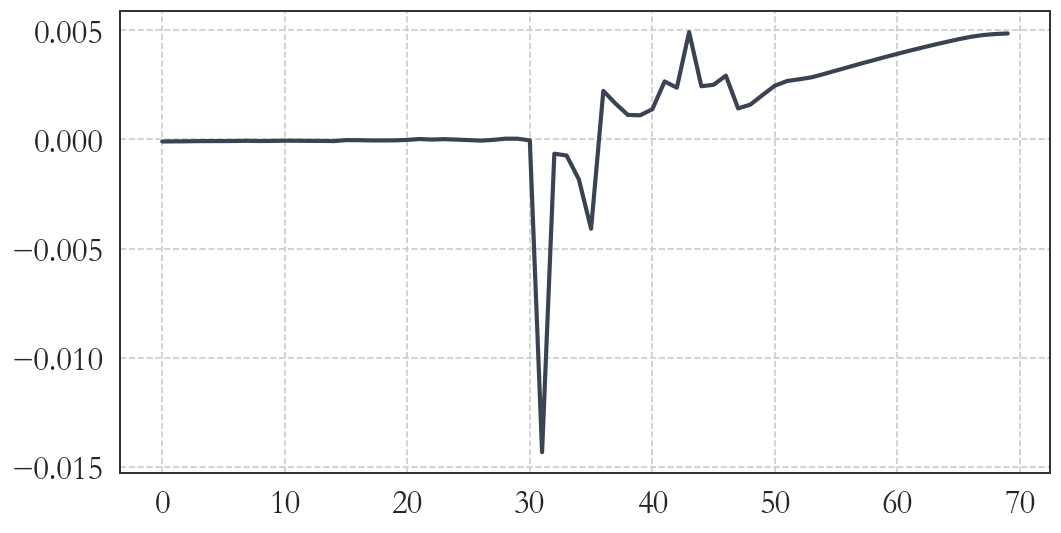

In [ ]:
t = 35

test_list = []

for t in range(70):
    model = og_model

    h = model.sim.h
    k = model.sim.k
    c = model.sim.c
    a = model.sim.a

    bq_old = bequest(model, a[:, t])
    util_old = utility_work(model, h[:,t], k[:,t], t)
    util_c_old = utility_consumption(model, c[:, t])

    model = new_model

    h = model.sim.h
    k = model.sim.k
    c = model.sim.c
    a = model.sim.a

    bq_new = bequest(model, a[:, t])
    util_new = utility_work(model, h[:,t], k[:,t], t)
    util_c_new = utility_consumption(model, c[:, t])

    test_list.append(np.mean(util_new) - np.mean(util_old) + np.mean(util_c_new) - np.mean(util_c_old) + (1-par.pi[t]) * (np.mean(bq_new) - np.mean(bq_old)))

plt.plot(test_list)

# print(np.mean(util_new) - np.mean(util_old))
# print(np.mean(util_c_new) - np.mean(util_c_old))
# print(np.mean(bq_new) - np.mean(bq_old))

# print(np.mean(util_new) - np.mean(util_old) + np.mean(util_c_new) - np.mean(util_c_old) + np.mean(bq_new) - np.mean(bq_old))


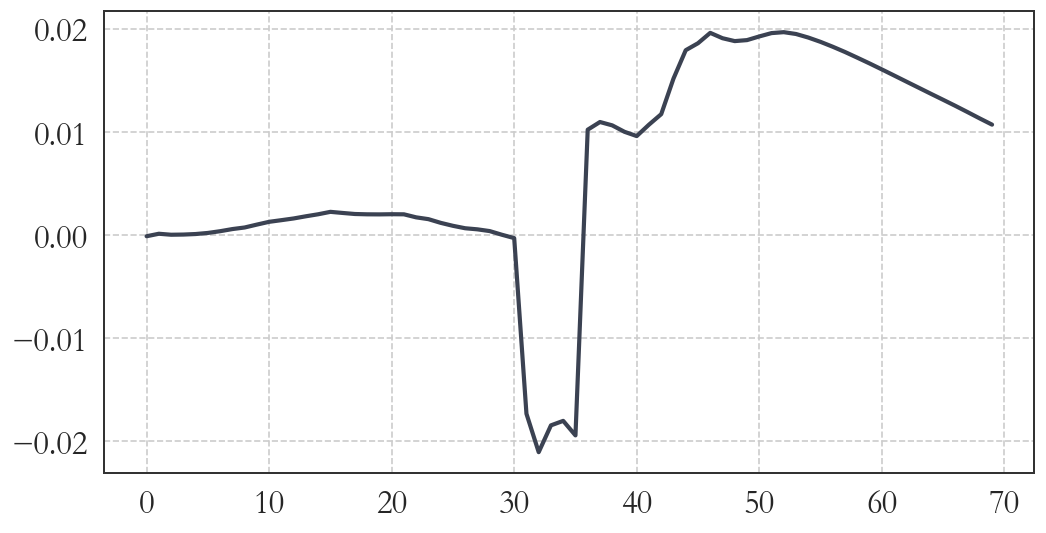

In [ ]:
EV_age_old, EV_weight_old, tc_old = ev_model(og_model)
EV_age_new, EV_weight_new, tc_new = ev_model(new_model)

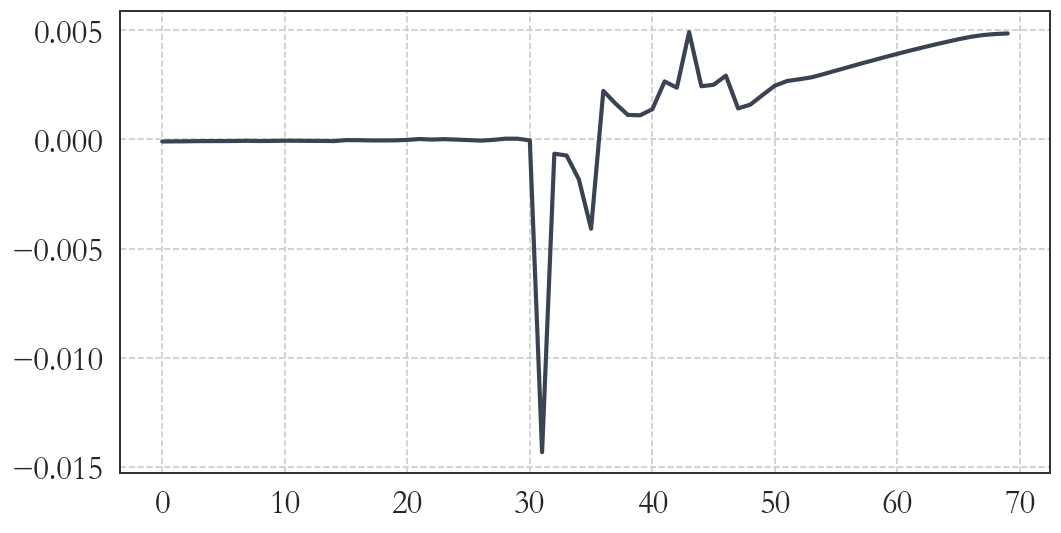

In [ ]:
plt.plot(np.array(tc_new) - np.array(tc_old))

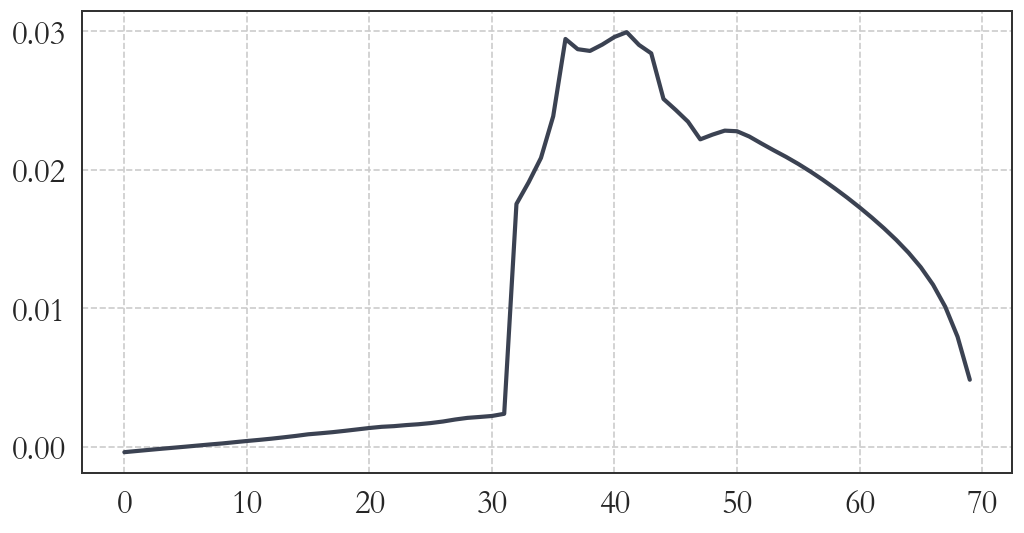

In [ ]:
plt.plot(np.array(EV_age_new) - np.array(EV_age_old))

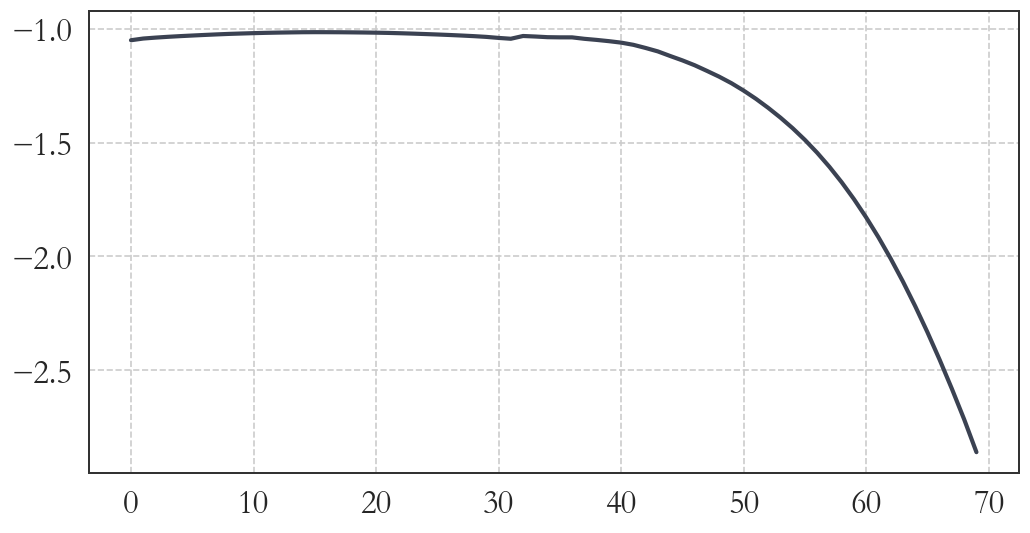

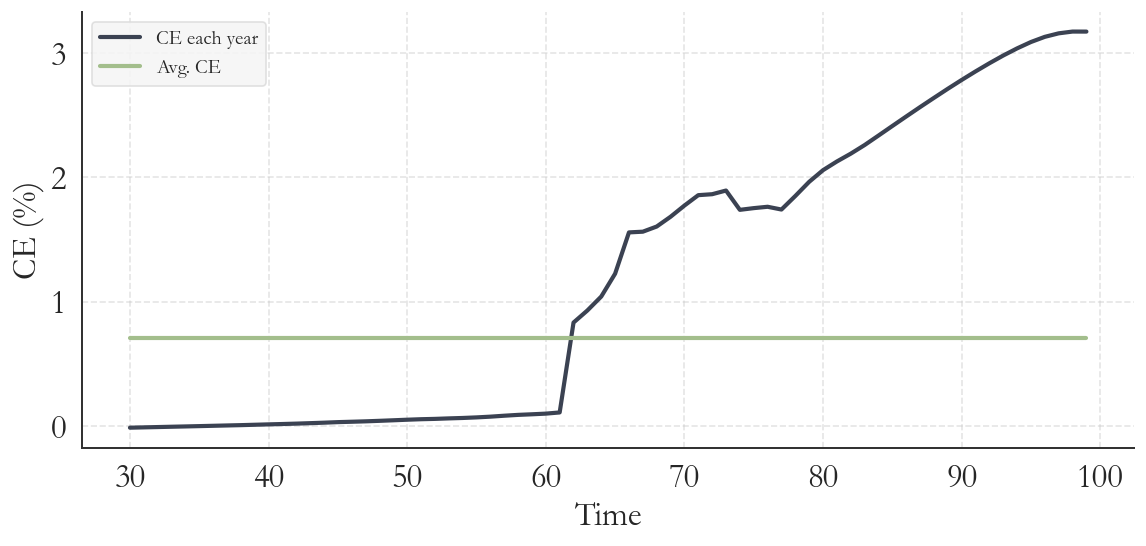

In [ ]:
EV_age_new, EV_weight_new = ev_model(new_model)
phi_age, phi_avg = analytical_age_phi(og_model, EV_age_new)
plot_single_line_with_reference(
    line_data=phi_age,
    reference_value=phi_avg,
    label_line="CE each year",
    label_ref="Avg. CE",
    ylabel="CE (%)",
    scale=100,
    save_title="CF_r_age_66_everything_CE_age.png"
)

# Comparison of means

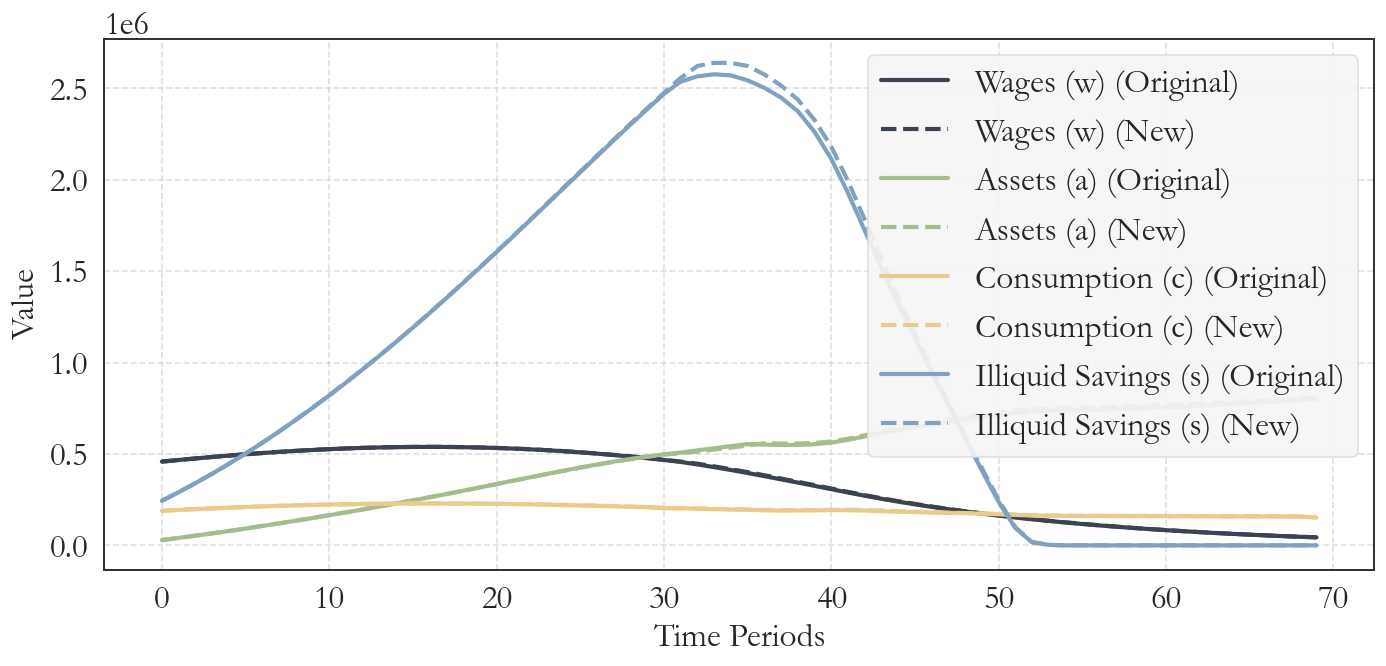

In [ ]:
time = np.arange(par.T)

# Data for selected summary variables
summary_vars = ["Wages (w)", "Assets (a)", "Consumption (c)", "Illiquid Savings (s)"]
simulated_data_new = {
    "Wages (w)": np.mean(new_model.sim.w[:], axis=0),
    "Assets (a)": np.mean(new_model.sim.a[:], axis=0),
    "Consumption (c)": np.mean(new_model.sim.c[:], axis=0),
    "Illiquid Savings (s)": np.mean(new_model.sim.s[:], axis=0),
}
simulated_data_og = {
    "Wages (w)": np.mean(og_model.sim.w[:], axis=0),
    "Assets (a)": np.mean(og_model.sim.a[:], axis=0),
    "Consumption (c)": np.mean(og_model.sim.c[:], axis=0),
    "Illiquid Savings (s)": np.mean(og_model.sim.s[:], axis=0),
}

plot_comparison_single_panel(simulated_data_og, simulated_data_new, summary_vars, time, save_title="CF_r_age_66_everything_means.png")
